In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from tqdm.keras import TqdmCallback

In [2]:
df1 = pd.read_csv("aligned_green_fashion_fixed.csv")
df2 = pd.read_csv("cleaned_green_fashion_fixed.csv")

data = pd.concat([df1, df2], ignore_index=True)

print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (200, 10)
                         name          brand  price  is_second_hand  \
0        Vintage Denim Jacket       OldStyle   1299            True   
1          Organic Cotton Tee       EcoRoots    799           False   
2   Recycled Polyester Hoodie      GreenWear    999           False   
3  Second Hand Leather Jacket     VintageHub   1499            True   
4             Eco Linen Shirt  NatureThreads    899           False   

   sustainability_score  eco_rating   category  \
0                   8.5         6.0  Outerwear   
1                   7.8         7.2       Tops   
2                   6.5         6.1       Tops   
3                   8.1         6.8  Outerwear   
4                   7.4         7.0       Tops   

                                         description  \
0   Well preserved denim jacket from previous season   
1  Soft organic cotton t-shirt eco friendly produ...   
2         Hoodie made from recycled polyester fibers   
3            Preowned l

In [3]:
data["name"] = data["name"].astype(str)
data["description"] = data["description"].astype(str)

data["text"] = data["name"] + " " + data["description"]

In [4]:
data["sustainability_score"] = pd.to_numeric(data["sustainability_score"], errors="coerce")

data["label"] = (data["sustainability_score"] > 7).astype(int)

data = data[["text","label"]]

print(data.head())

                                                text  label
0  Vintage Denim Jacket Well preserved denim jack...      1
1  Organic Cotton Tee Soft organic cotton t-shirt...      1
2  Recycled Polyester Hoodie Hoodie made from rec...      0
3  Second Hand Leather Jacket Preowned leather ja...      1
4  Eco Linen Shirt Breathable linen shirt made su...      1


In [5]:
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data["text"])

X = tokenizer.texts_to_sequences(data["text"])
X = pad_sequences(X, maxlen=max_len)

y = data["label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [7]:
input_layer = Input(shape=(max_len,))

x = Embedding(max_words,128)(input_layer)

x = Conv1D(64,5,activation="relu")(x)
x = MaxPooling1D(2)(x)

x = LSTM(64)(x)

x = Dropout(0.5)(x)

output = Dense(1,activation="sigmoid")(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 100, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 96, 64)              │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 714,113 (2.72 MB)

 Trainable params: 714,113 (2.72 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(patience=3)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, TqdmCallback(verbose=1)],
    verbose=0
)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

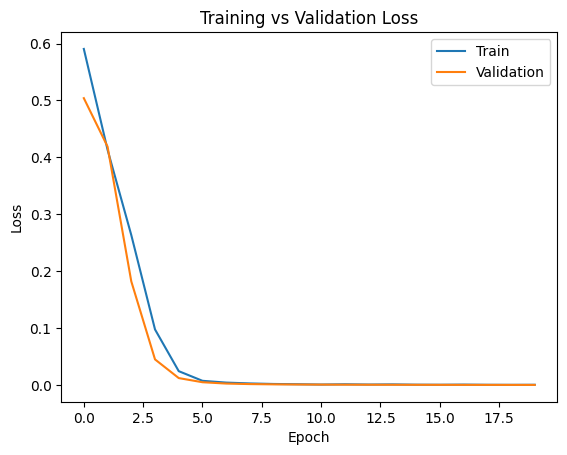

In [9]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])
plt.show()

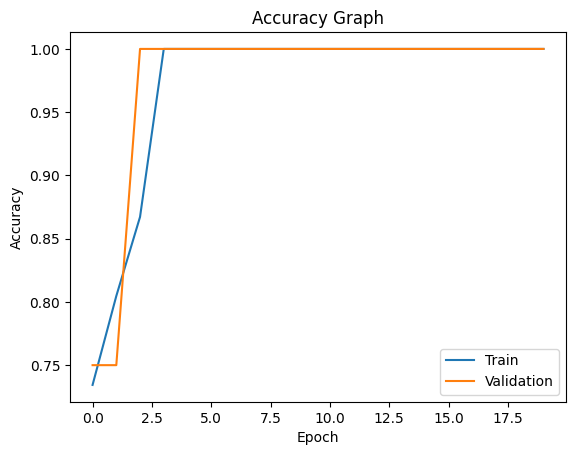

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [11]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 831ms/step


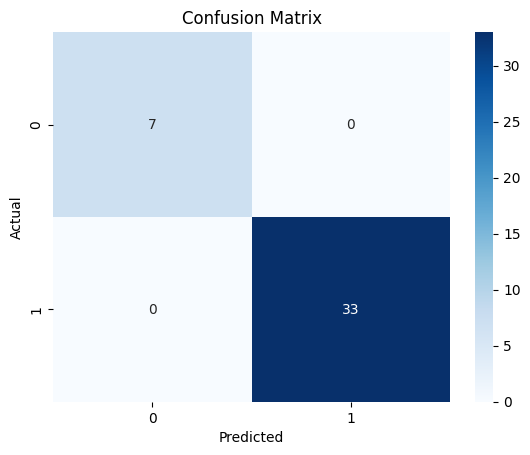

In [12]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        33

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



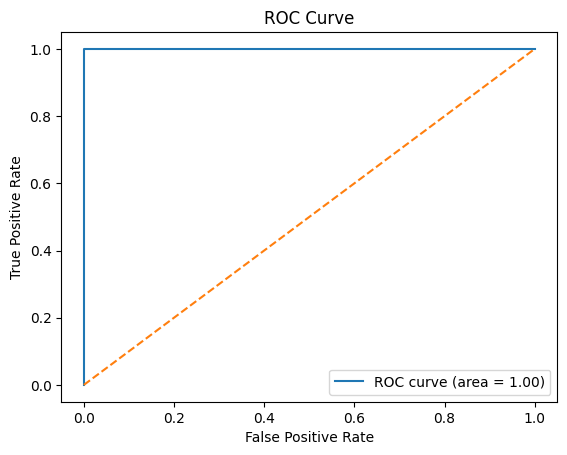

In [14]:
fpr,tpr,_ = roc_curve(y_test,y_prob)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

In [15]:
model.save("cnn_lstm_green_fashion_model.h5")

print("Model saved successfully")

Model saved successfully


In [16]:
def predict_text(text):

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq,maxlen=max_len)

    pred = model.predict(padded)[0][0]

    if pred > 0.5:
        print("Sustainable product")
    else:
        print("Non sustainable product")

predict_text("eco friendly organic cotton shirt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
Sustainable product
